# Monthly Stock Analysis Based on WRDS CSMAR

## Introduction
This notebook presents a simple monthly stock analysis framework using data from the **WRDS CSMAR** database.

The main objective is to retrieve and analyse the monthly trading performance of a selected stock.  
The notebook includes:

- data retrieval from WRDS
- data cleaning and preprocessing
- descriptive statistical analysis
- visualisation of return and price dynamics
- simple analytical interpretation
- export of processed results to Excel

## Data Source
The dataset is obtained from:

- **Database**: WRDS
- **Library**: CSMAR
- **Table**: `csmar.trd_mnth`

## Variables Used
The following variables are used in this analysis:

- `stkcd`: stock code
- `trdmnt`: trading month
- `mclsprc`: monthly closing price
- `mretwd`: monthly return with cash dividend reinvested
- `mretnd`: monthly return without cash dividend reinvested
- `mnshrtrd`: monthly trading volume
- `mnvaltrd`: monthly trading value

## Research Purpose
This notebook aims to answer the following questions:

1. What are the monthly return characteristics of the selected stock?
2. What is the trend in the stock’s cumulative performance?
3. How has the stock’s monthly closing price evolved over time?
4. What insights can be drawn from the descriptive statistics?

## 1. Import Required Libraries

In this section, the Python libraries required for data retrieval, processing, visualisation, and export are imported.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import wrds
from io import BytesIO

## 2. User Input

This section collects the user-defined parameters for the analysis, including:

- WRDS username
- stock code
- starting month for the sample period

The starting month should be entered in `YYYYMM` format.

In [1]:
wrds_username = input("Enter your WRDS username: ").strip()
stock_code = input("Enter stock code: ").strip()
start_month = input("Enter start month (YYYYMM): ").strip()

if wrds_username == "":
    raise ValueError("WRDS username cannot be empty.")

if stock_code == "":
    raise ValueError("Stock code cannot be empty.")

try:
    start_month = int(start_month)
except:
    raise ValueError("Start month must be in numeric YYYYMM format.")

Enter your WRDS username:  xiaoyashi24
Enter stock code:  000001
Enter start month (YYYYMM):  202101


In [4]:
db = wrds.Connection(wrds_username='xiaoyashi24')
print("Connected to WRDS successfully.")

Loading library list...
Done
Connected to WRDS successfully.


## 3. Data Retrieval from CSMAR

This section retrieves monthly stock data from the `csmar.trd_mnth` table.

The query selects all observations for the chosen stock code from the specified starting month onward.

In [5]:
query = f"""
SELECT stkcd, trdmnt, mclsprc, mretwd, mretnd, mnshrtrd, mnvaltrd
FROM csmar.trd_mnth
WHERE stkcd = '{stock_code}'
  AND trdmnt >= {start_month}
"""

print("SQL Query:")
print(query)

df = db.raw_sql(query)
print("Raw data shape:", df.shape)
df.head()

SQL Query:

SELECT stkcd, trdmnt, mclsprc, mretwd, mretnd, mnshrtrd, mnvaltrd
FROM csmar.trd_mnth
WHERE stkcd = '000001'
  AND trdmnt >= 202101

Raw data shape: (48, 7)


,stkcd,trdmnt,mclsprc,mretwd,mretnd,mnshrtrd,mnvaltrd
0,000001,202101,23.09,0.193899,0.193899,2792512935.0,58603803798.230003
1,000001,202102,21.38,-0.074058,-0.074058,2243272525.0,52541944392.309998
2,000001,202103,22.01,0.029467,0.029467,2340059951.0,50347476182.970001
3,000001,202104,23.29,0.058155,0.058155,1423476303.0,31264829462.849998
4,000001,202105,24.2,0.047092,0.046801,1015281590.0,24221421505.84


## 4. Initial Inspection of Raw Data

Before cleaning, the raw dataset is briefly inspected to understand its dimensions and structure.

In [6]:
print("Number of rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head(10)

Number of rows and columns: (48, 7)

Column names:
['stkcd', 'trdmnt', 'mclsprc', 'mretwd', 'mretnd', 'mnshrtrd', 'mnvaltrd']


,stkcd,trdmnt,mclsprc,mretwd,mretnd,mnshrtrd,mnvaltrd
0,000001,202101,23.09,0.193899,0.193899,2792512935.0,58603803798.230003
1,000001,202102,21.38,-0.074058,-0.074058,2243272525.0,52541944392.309998
2,000001,202103,22.01,0.029467,0.029467,2340059951.0,50347476182.970001
3,000001,202104,23.29,0.058155,0.058155,1423476303.0,31264829462.849998
4,000001,202105,24.2,0.047092,0.046801,1015281590.0,24221421505.84
5,000001,202106,22.62,-0.065289,-0.065289,1225673158.0,28598633960.799999
6,000001,202107,17.69,-0.217949,-0.217949,1935733252.0,39543208925.129997
7,000001,202108,17.8,0.006218,0.006218,2087476977.0,39612873638.029999
8,000001,202109,17.93,0.007303,0.007303,2752985795.0,51002547278.610001
9,000001,202110,19.5,0.087563,0.087563,1435194523.0,28042460454.439999


## 5. Data Cleaning and Preprocessing

The following cleaning steps are performed:

1. Keep only relevant columns
2. Remove observations with missing key values
3. Convert the trading month from `YYYYMM` format to datetime
4. Sort observations chronologically
5. Create additional variables for analysis

### Derived Variables
Two derived variables are created:

- `cum_return`: cumulative return over time
- `price_change`: month-to-month change in closing price

In [7]:
if df.empty:
    raise ValueError("No data found. Please check the stock code or start month.")

df = df[['stkcd', 'trdmnt', 'mclsprc', 'mretwd', 'mretnd', 'mnshrtrd', 'mnvaltrd']].copy()

df = df.dropna(subset=['trdmnt', 'mretwd', 'mclsprc'])

df['trdmnt'] = pd.to_datetime(df['trdmnt'].astype(str), format='%Y%m', errors='coerce')
df = df.dropna(subset=['trdmnt'])

if df.empty:
    raise ValueError("Data became empty after cleaning. No valid observations remain.")

df = df.sort_values('trdmnt').reset_index(drop=True)
df['year_month'] = df['trdmnt'].dt.strftime('%Y-%m')
df['cum_return'] = (1 + df['mretwd']).cumprod() - 1
df['price_change'] = df['mclsprc'].diff()

print("Cleaned data shape:", df.shape)
df.head(10)

Cleaned data shape: (48, 10)


,stkcd,trdmnt,mclsprc,mretwd,mretnd,mnshrtrd,mnvaltrd,year_month,cum_return,price_change
0,000001,2021-01-01,23.09,0.193899,0.193899,2792512935.0,58603803798.230003,2021-01,0.193899,<NA>
1,000001,2021-02-01,21.38,-0.074058,-0.074058,2243272525.0,52541944392.309998,2021-02,0.105481,-1.71
2,000001,2021-03-01,22.01,0.029467,0.029467,2340059951.0,50347476182.970001,2021-03,0.138056,0.63
3,000001,2021-04-01,23.29,0.058155,0.058155,1423476303.0,31264829462.849998,2021-04,0.20424,1.28
4,000001,2021-05-01,24.2,0.047092,0.046801,1015281590.0,24221421505.84,2021-05,0.26095,0.91
5,000001,2021-06-01,22.62,-0.065289,-0.065289,1225673158.0,28598633960.799999,2021-06,0.178624,-1.58
6,000001,2021-07-01,17.69,-0.217949,-0.217949,1935733252.0,39543208925.129997,2021-07,-0.078256,-4.93
7,000001,2021-08-01,17.8,0.006218,0.006218,2087476977.0,39612873638.029999,2021-08,-0.072525,0.11
8,000001,2021-09-01,17.93,0.007303,0.007303,2752985795.0,51002547278.610001,2021-09,-0.065751,0.13
9,000001,2021-10-01,19.5,0.087563,0.087563,1435194523.0,28042460454.439999,2021-10,0.016054,1.57


## 6. Descriptive Statistical Analysis

This section summarises the return and price characteristics of the selected stock.

The following indicators are reported:

### Return Statistics
- average monthly return
- return volatility
- highest monthly return
- lowest monthly return

### Price Statistics
- average monthly closing price
- price volatility
- highest monthly closing price
- lowest monthly closing price

In [8]:
mean_return = df['mretwd'].mean()
std_return = df['mretwd'].std()
max_return = df['mretwd'].max()
min_return = df['mretwd'].min()

mean_price = df['mclsprc'].mean()
std_price = df['mclsprc'].std()
max_price = df['mclsprc'].max()
min_price = df['mclsprc'].min()

summary_df = pd.DataFrame({
    "Metric": [
        "Average monthly return",
        "Return volatility (std)",
        "Highest monthly return",
        "Lowest monthly return",
        "Average monthly closing price",
        "Price volatility (std)",
        "Highest monthly closing price",
        "Lowest monthly closing price"
    ],
    "Value": [
        mean_return,
        std_return,
        max_return,
        min_return,
        mean_price,
        std_price,
        max_price,
        min_price
    ]
})

summary_df

,Metric,Value
0,Average monthly return,-0.003773
1,Return volatility (std),0.088961
2,Highest monthly return,0.260155
3,Lowest monthly return,-0.217949
4,Average monthly closing price,14.150625
5,Price volatility (std),4.149812
6,Highest monthly closing price,24.200000
7,Lowest monthly closing price,9.390000


## 7. Best and Worst Performing Months

To better understand performance extremes, the notebook identifies:

- the month with the highest monthly return
- the month with the lowest monthly return

In [9]:
valid_return_df = df.dropna(subset=['mretwd'])

if valid_return_df.empty:
    raise ValueError("No valid return observations available.")

best_month = valid_return_df.loc[valid_return_df['mretwd'].idxmax()]
worst_month = valid_return_df.loc[valid_return_df['mretwd'].idxmin()]

print("Best-performing month")
print("----------------------")
print("Month:", best_month['trdmnt'].strftime('%Y-%m'))
print("Return:", round(best_month['mretwd'], 4))

print("\nWorst-performing month")
print("----------------------")
print("Month:", worst_month['trdmnt'].strftime('%Y-%m'))
print("Return:", round(worst_month['mretwd'], 4))

Best-performing month
----------------------
Month: 2022-11
Return: 0.2602

Worst-performing month
----------------------
Month: 2021-07
Return: -0.2179


## 8. Visualisation of Monthly Stock Performance

Visualisation is used to better illustrate the stock’s return and price dynamics.

The following charts are presented:

1. monthly return trend
2. cumulative return trend
3. monthly closing price trend
4. monthly return bar chart

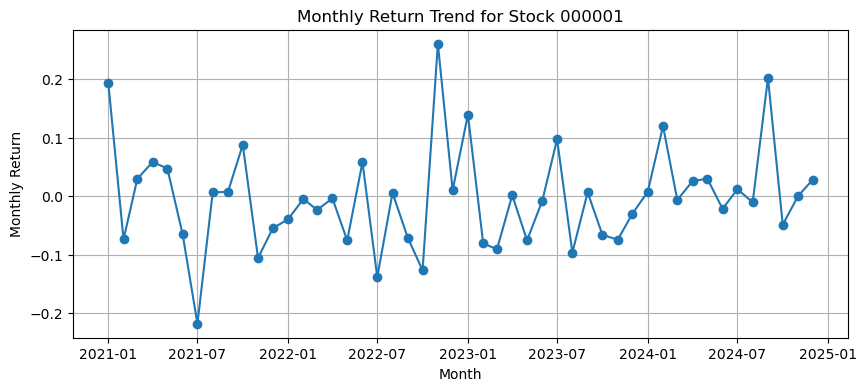

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(df['trdmnt'], df['mretwd'], marker='o')
plt.title(f'Monthly Return Trend for Stock {stock_code}')
plt.xlabel('Month')
plt.ylabel('Monthly Return')
plt.grid(True)
plt.show()

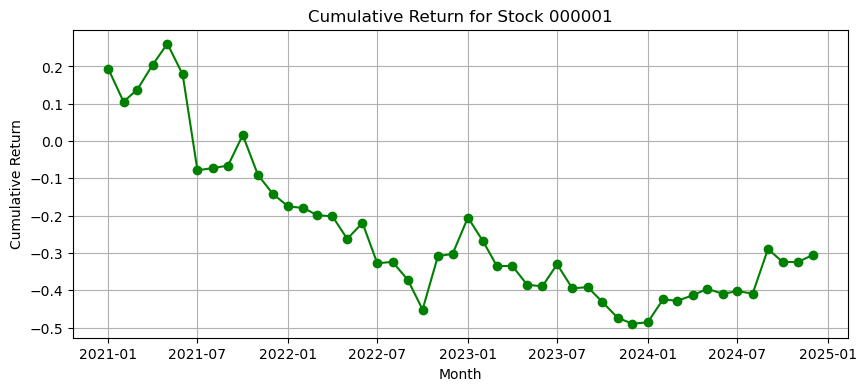

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(df['trdmnt'], df['cum_return'], marker='o', color='green')
plt.title(f'Cumulative Return for Stock {stock_code}')
plt.xlabel('Month')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()

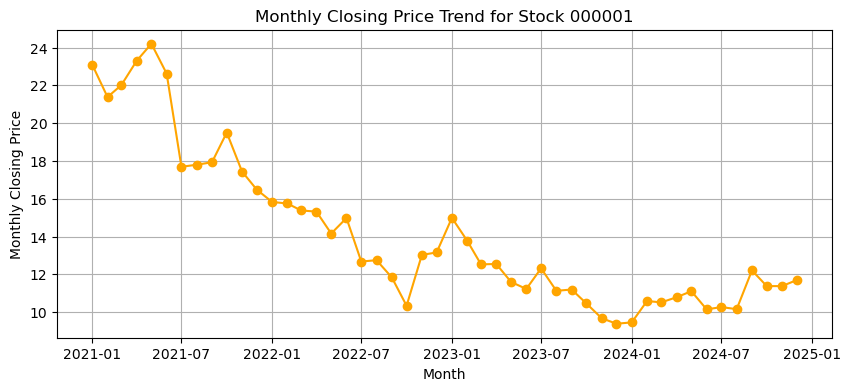

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(df['trdmnt'], df['mclsprc'], marker='o', color='orange')
plt.title(f'Monthly Closing Price Trend for Stock {stock_code}')
plt.xlabel('Month')
plt.ylabel('Monthly Closing Price')
plt.grid(True)
plt.show()

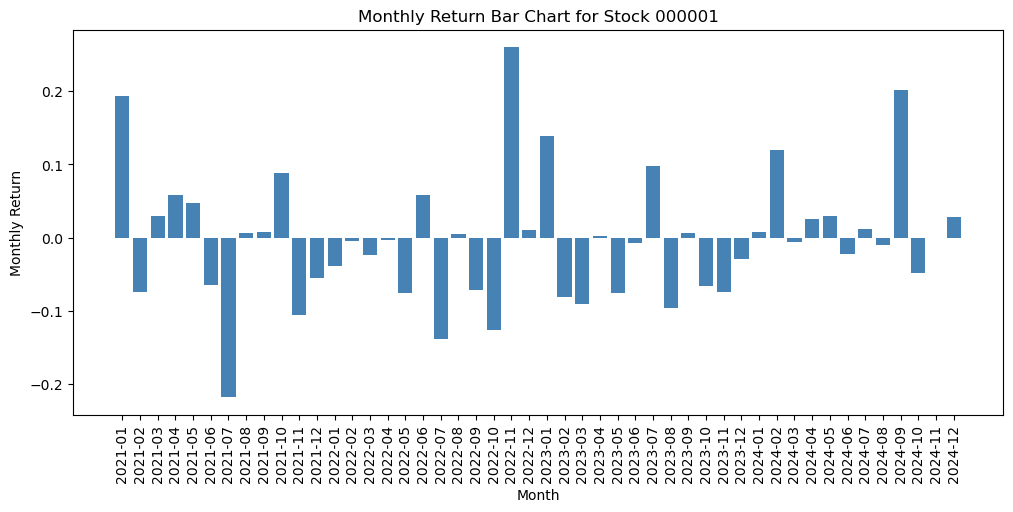

In [13]:
plt.figure(figsize=(12, 5))
plt.bar(df['year_month'].astype(str), df['mretwd'], color='steelblue')
plt.title(f'Monthly Return Bar Chart for Stock {stock_code}')
plt.xlabel('Month')
plt.ylabel('Monthly Return')
plt.xticks(rotation=90)
plt.show()

## 9. Analytical Interpretation

Based on the descriptive statistics and visualisations, several basic insights can be summarised.

These observations are intended to provide an initial interpretation of the stock’s monthly performance rather than a full econometric analysis.

In [14]:
insights = []

if mean_return > 0:
    insights.append(f"Stock {stock_code} delivered a positive average monthly return over the selected period.")
else:
    insights.append(f"Stock {stock_code} delivered a negative average monthly return over the selected period.")

if std_return > 0.1:
    insights.append("The stock shows relatively high volatility in monthly returns.")
else:
    insights.append("The stock shows relatively moderate monthly return volatility.")

insights.append(
    f"The best-performing month was {best_month['trdmnt'].strftime('%Y-%m')}, "
    f"with a return of {best_month['mretwd']:.4f}."
)

insights.append(
    f"The worst-performing month was {worst_month['trdmnt'].strftime('%Y-%m')}, "
    f"with a return of {worst_month['mretwd']:.4f}."
)

if df['cum_return'].iloc[-1] > 0:
    insights.append("Overall cumulative return is positive over the selected period.")
else:
    insights.append("Overall cumulative return is negative over the selected period.")

if df['mclsprc'].iloc[-1] > df['mclsprc'].iloc[0]:
    insights.append("The monthly closing price shows an overall upward trend.")
else:
    insights.append("The monthly closing price does not show a clear upward trend.")

for i, item in enumerate(insights, start=1):
    print(f"{i}. {item}")

1. Stock 000001 delivered a negative average monthly return over the selected period.
2. The stock shows relatively moderate monthly return volatility.
3. The best-performing month was 2022-11, with a return of 0.2602.
4. The worst-performing month was 2021-07, with a return of -0.2179.
5. Overall cumulative return is negative over the selected period.
6. The monthly closing price does not show a clear upward trend.


## 10. Final Processed Dataset

The cleaned and enriched dataset is displayed below for reference.

In [15]:
df

,stkcd,trdmnt,mclsprc,mretwd,mretnd,mnshrtrd,mnvaltrd,year_month,cum_return,price_change
0,000001,2021-01-01,23.09,0.193899,0.193899,2792512935.0,58603803798.230003,2021-01,0.193899,<NA>
1,000001,2021-02-01,21.38,-0.074058,-0.074058,2243272525.0,52541944392.309998,2021-02,0.105481,-1.71
2,000001,2021-03-01,22.01,0.029467,0.029467,2340059951.0,50347476182.970001,2021-03,0.138056,0.63
3,000001,2021-04-01,23.29,0.058155,0.058155,1423476303.0,31264829462.849998,2021-04,0.20424,1.28
4,000001,2021-05-01,24.2,0.047092,0.046801,1015281590.0,24221421505.84,2021-05,0.26095,0.91
5,000001,2021-06-01,22.62,-0.065289,-0.065289,1225673158.0,28598633960.799999,2021-06,0.178624,-1.58
6,000001,2021-07-01,17.69,-0.217949,-0.217949,1935733252.0,39543208925.129997,2021-07,-0.078256,-4.93
7,000001,2021-08-01,17.8,0.006218,0.006218,2087476977.0,39612873638.029999,2021-08,-0.072525,0.11
8,000001,2021-09-01,17.93,0.007303,0.007303,2752985795.0,51002547278.610001,2021-09,-0.065751,0.13
9,000001,2021-10-01,19.5,0.087563,0.087563,1435194523.0,28042460454.439999,2021-10,0.016054,1.57


## 11. Export Results

To facilitate further use, the processed dataset and summary statistics are exported to an Excel file.

In [16]:
output_file = f"{stock_code}_monthly_stock_analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df.to_excel(writer, index=False, sheet_name="Processed_Data")
    summary_df.to_excel(writer, index=False, sheet_name="Summary_Statistics")

print(f"Excel file saved as: {output_file}")

Excel file saved as: 000001_monthly_stock_analysis.xlsx


## 12. Conclusion

This notebook demonstrated how monthly stock data can be retrieved from WRDS CSMAR and analysed using Python.

The analysis provided:
- a structured data cleaning workflow
- descriptive statistics on return and price behaviour
- graphical illustrations of stock performance
- simple analytical insights for interpretation

This framework can be extended in future work by incorporating:
- benchmark comparison
- risk-adjusted performance measures
- event-study style analysis
- multiple stock comparison
- regression-based empirical analysis